In [1]:
# Cellule 1 : Imports et configuration
%load_ext autoreload
%autoreload 2

import pandas as pd

# Import des classe et fonctions personnalisées
from tools.OI_class_v2 import OI_DataProcessor
from tools.OI_utils import extract_xls,analyser_correlation_croisee

# Configuration de l'affichage pour voir toutes les colonnes
pd.set_option('display.max_columns', None)

In [2]:
tags = [
        {'tag':'WQ33222VA', 'nom':'Ester','info':'Totalisation du Peson Acetate/Propionate' },
        {'tag':'3340_type', 'nom':'A/P','info':'Acetate ou Propionate' },
        {'tag':'CTY_ACV43A_Teneur Vit. A (UV)', 'nom':'Acetate_UV','info':'ACV43A teneur en acetate'},
        {'tag':'CTY_A3340FGB_Teneur arr. Vit. A (UV)', 'nom':'Propionate_UV', 'info':'A3340FGB teneur en propionate'},
        {'tag':'PU3310VA_Sign','nom':'PU3310','info':'signature du PU3310'},
        {'tag':'PU3320VA_Sign','nom':'PU3320','info':'signature du PU3320'},
        {'tag':'PU3340VA_Sign','nom':'PU3340','info':'signature du PU3340'},
        {'tag':'FQ32202VA_UV','nom':'Hexane','info':'VA diluée dans de l\'hexane'},
        {'tag':'CTY_A3230A_Teneur en rétinol', 'nom':'Retinol_UV','info':'A3230A teneur en rétinol lavé'},
        {'tag':'LI33203VA','nom':'R33020','info':'niveau du R33020'},
        {'tag':'LI33218VA','nom':'R33022','info':'niveau du R33022'},
        {'tag':'LI33225VA','nom':'R33061','info':'niveau du R33061'},
        {'tag':'WI33222VA','nom':'R33060','info':'peson du R33060'},
        {'tag':'FQ32202VA','nom':'Retinol','info':'Consommation rétinol phase Ester'},
    ]

In [24]:
produits = [
    { 'batchs' : [
        {'tag':'PU3310', 'min':540, 'max':710, 'value':'Hexane', 'uv':'Retinol_UV', 'scale':1/825/100., 'default':2.71, 'cond':None, 'val_cond': None},
        {'tag':'PU3310', 'min':710, 'max':2320, 'value':None, 'uv':None, 'scale':2.71, 'default':0, 'cond':None, 'val_cond':None},
        {'tag':'PU3320', 'min':430, 'max':2020, 'value':None, 'uv':None, 'scale':2.71, 'default':0, 'cond':None, 'val_cond':None},
        {'tag':'PU3340', 'min':0, 'max':710, 'value':'R33060', 'uv':None, 'scale':0.95, 'default':0, 'cond':'A/P', 'val_cond':[1/344,1/359]},
    ],
     'continus' : [
        {'tag':'R33020', 'min': 14,  'epalage': [[28.62,21.22,3.866,-0.0983], [-228.84,74.557]], 'uv':'Retinol_UV', 'scale':1/100., 'cond':'A/P', 'val_cond':[1/344,1/359] },
        {'tag':'R33022', 'min': 14,  'epalage': [[6.25,5.4525,0.898,-0.0256], [-35,97,16.039]], 'uv':'Retinol_UV', 'scale':1/100., 'cond':'A/P', 'val_cond':[1/344,1/359] },
        {'tag':'R33061', 'min': 18,  'epalage': [[0.69,0.72,0.296,-0.0059], [-30.03,5.836]], 'uv':None, 'scale':0.95, 'cond':'A/P', 'val_cond':[1/344,1/359] },
    ] } ,
    { 'continus' : [
        {'tag': 'COUcou', 'min' :12 }
    ] }
]


In [28]:
# Initialisation
processor = OI_DataProcessor(
    url_base = 'https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?',
    tags_other = [],
    tags_selected = tags,
    start='2026-05-12',
    end='2026-05-14',
    interval='PT1H',
    verbose=False
)

# Charger les données
processor.merge()

# Appliquer des filtres (chaînage possible)
processor.filtering(
    tag=['Ester'],
    min_val=[0],
    max_val=[10_000_000],
    na=['Ester']
)

# Ajouter des colonnes
processor.ajoute_calcul('Ester','A/P','Acetate_UV','Propionate_UV',1e-9,'cumul')
#processor.ajoute_batch(batchs[3],'batchs')
#processor.ajoute_continus(continus[0],'continus')
processor.ajoute_all_batchs(produits[0]['batchs'],'batchs')
processor.ajoute_all_continus(produits[0]['continus'],'continus')
#processor.ajoute_cumul('A1000M_Poids', 'A1000M_UV_Auto', 1000, 'Cumul_UV')
#processor.ajouter_moyennes_glissantes_ponderee('A1000M_Poids', 'A1000M_UV_Auto', 'A1000M_Moyenne_UV', window=15)
#processor.ajouter_moyennes_glissantes('Acetate_UV', 'Acetate_Moyenne_UV', window=15)

# Afficher les infos finales
processor.info()
#processor.data

INFORMATIONS DataProcessor
URL de base       : https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?
Tags autres       : []
Tags sélectionnés : [{'tag': 'WQ33222VA', 'nom': 'Ester', 'info': 'Totalisation du Peson Acetate/Propionate'}, {'tag': '3340_type', 'nom': 'A/P', 'info': 'Acetate ou Propionate'}, {'tag': 'CTY_ACV43A_Teneur Vit. A (UV)', 'nom': 'Acetate_UV', 'info': 'ACV43A teneur en acetate'}, {'tag': 'CTY_A3340FGB_Teneur arr. Vit. A (UV)', 'nom': 'Propionate_UV', 'info': 'A3340FGB teneur en propionate'}, {'tag': 'PU3310VA_Sign', 'nom': 'PU3310', 'info': 'signature du PU3310'}, {'tag': 'PU3320VA_Sign', 'nom': 'PU3320', 'info': 'signature du PU3320'}, {'tag': 'PU3340VA_Sign', 'nom': 'PU3340', 'info': 'signature du PU3340'}, {'tag': 'FQ32202VA_UV', 'nom': 'Hexane', 'info': "VA diluée dans de l'hexane"}, {'tag': 'CTY_A3230A_Teneur en rétinol', 'nom': 'Retinol_UV', 'info': 'A3230A teneur en rétinol lavé'}, {'tag': 'LI33203VA', 'nom': 'R33020', 'info': 'niveau du R3

In [6]:
# 1. On veut changer de date ?
processor.start = '2026-01-01'
processor.end = '2026-12-31'
processor.interval = 'PT10M'

# 2. On recalcule TOUT (merge + filtres + cumul) en une commande
processor.recalculate()

# 3. On vérifie le pipeline
processor.show_pipeline()
processor.info()
processor.data.describe()


--- PIPELINE ACTUEL ---
1. filtering | Args: () | Kwargs: {'tag': ['Ester'], 'min_val': [0], 'max_val': [10000000], 'na': ['Ester']}
2. ajoute_calcul | Args: ('Ester', 'A/P', 'Acetate_UV', 'Propionate_UV', 1e-09, 'cumul') | Kwargs: {}
3. ajoute_all_batchs | Args: ([{'tag': 'PU3310', 'min': 540, 'max': 710, 'value': 'Hexane', 'uv': 'Retinol_UV', 'scale': 1.2121212121212122e-05, 'default': 2.71, 'cond': None, 'val_cond': None}, {'tag': 'PU3310', 'min': 710, 'max': 2320, 'value': None, 'uv': None, 'scale': 2.71, 'default': 0, 'cond': None, 'val_cond': None}, {'tag': 'PU3320', 'min': 430, 'max': 2020, 'value': None, 'uv': None, 'scale': 2.71, 'default': 0, 'cond': None, 'val_cond': None}, {'tag': 'PU3340', 'min': 0, 'max': 710, 'value': 'R33060', 'uv': None, 'scale': 0.95, 'default': 0, 'cond': 'A/P', 'val_cond': [0.0029069767441860465, 0.002785515320334262]}], 'batchs') | Kwargs: {}
4. ajoute_all_continus | Args: ([{'tag': 'R33020', 'min': 14, 'epalage': [[28.62, 21.22, 3.866, -0.0983], 

,Ester,A/P,Acetate_UV,Propionate_UV,PU3310,PU3320,PU3340,Hexane,Retinol_UV,R33020,R33022,R33061,R33060,Retinol,cumul,batchs,continus
count,2.120300e+04,21203.000000,2.120300e+04,2.120300e+04,21194.000000,21196.000000,21193.000000,21203.000000,21203.000000,21203.000000,21203.000000,21203.000000,21203.000000,21203.000000,21203.000000,21203.000000,21203.000000
mean,2.442969e+06,0.078387,2.226086e+06,2.283856e+06,1014.501919,942.447208,461.931914,2571.038674,20.794441,45.583838,4.930974,7.201319,684.013505,455985.199784,493.815210,4.496831,2.020293
std,1.385180e+05,0.268688,3.910248e+04,4.950395e+04,612.076371,539.118241,114.691379,1878.938704,0.373676,20.427537,2.438133,11.341622,351.694469,251551.570212,309.821351,2.009196,0.949147
min,2.221310e+06,0.000000,2.078915e+06,2.188000e+06,100.000000,100.000000,154.366667,0.000000,20.000000,-8.110888,-0.695313,-0.580579,5.626313,599.123256,0.000000,0.000000,0.013995
25%,2.312340e+06,0.000000,2.221983e+06,2.242000e+06,400.000000,400.000000,410.000000,0.000000,20.600000,23.822076,3.324957,2.187726,417.979693,247246.000000,202.139712,3.296255,0.989934
50%,2.425060e+06,0.000000,2.230864e+06,2.314000e+06,1310.000000,1110.000000,410.000000,3945.870000,20.800000,44.880885,5.956514,2.880866,680.268750,420231.000000,452.005752,4.659799,2.023067
75%,2.565774e+06,0.000000,2.245768e+06,2.314000e+06,1310.000000,1266.802083,410.000000,4039.040000,21.200000,64.555995,6.492190,3.948257,944.800519,651835.000000,768.493141,5.599523,2.898383
max,2.699540e+06,1.000000,2.325113e+06,2.626000e+06,2320.150000,2253.316667,810.000000,4836.070000,21.200000,91.624845,12.286763,75.879685,1322.656047,998136.625000,1070.111728,8.997205,4.116169


In [7]:
processor.data.batchs.value_counts()

batchs
2.710000    1552
5.420000     892
0.000000     263
0.052266      35
2.739127      19
            ... 
3.056199       1
3.147967       1
3.227007       1
3.312417       1
4.829045       1
Name: count, Length: 18193, dtype: int64

In [8]:
nb = processor.data['Ester'].size
ester = (processor.data.iloc[-1]['cumul'] - processor.data.iloc[0]['cumul'])
deltaBatch = processor.data.iloc[-1]['batchs'] - processor.data.iloc[0]['batchs']
deltaContinus = processor.data.iloc[-1]['continus'] - processor.data.iloc[0]['continus']
print(nb, ester + deltaBatch +deltaContinus, ester,  deltaBatch, deltaContinus)
stock_entree = processor.data.iloc[0]['batchs'] + processor.data.iloc[0]['continus']
stock_sortie = processor.data.iloc[-1]['batchs'] + processor.data.iloc[-1]['continus']

print('stock entrée :', stock_entree)
print('stock sortie :', stock_sortie)
print('variation stock :', stock_sortie - stock_entree)
print('Consommation :', ester)
print('production :', deltaBatch + deltaContinus+ ester)

21203 1069.9497755701427 1070.1117277913208 0.0880292676033596 -0.24998148878156168
stock entrée : 5.8369571646290614
stock sortie : 5.675004943450859
variation stock : -0.1619522211782023
Consommation : 1070.1117277913208
production : 1069.9497755701427


In [9]:
def calcul_cumul_mensuel(processor, mois, annee=None, std=2):
    """
    Calcule le cumul, delta batch et delta continu pour un mois donne depuis processor.data.
    Le calcul s'effectue du 1er du mois a 3:00 au 1er du mois suivant a 3:00.
    Si le mois n'est pas termine, les valeurs sont calculees "a date" (jusqu'a la derniere donnee disponible).
    
    Parameters:
    -----------
    processor : OI_DataProcessor
        L'objet processor contenant le DataFrame data.
    mois : int, str
        Le mois a calculer. Peut etre un entier (ex: 5), une chaine (ex: '05', '2026-05', 'mai').
    annee : int, optional
        L'annee a calculer. Si non fournie, elle est deduite des donnees du processor (par defaut 2026).
        
    Returns:
    --------
    dict : Dictionnaire contenant les resultats du calcul.
    """
    df = processor.data
    if df is None or df.empty:
        print("Erreur : Les donnees du processeur (processor.data) sont vides.")
        return None
        
    # Deduction de l'annee si non specifiee
    if annee is None:
        annee = df.index.year[0]
        
    # Parsing du mois
    month_num = None
    if isinstance(mois, int):
        month_num = mois
    elif isinstance(mois, str):
        mois_clean = mois.strip().lower()
        if '-' in mois_clean:
            try:
                parts = mois_clean.split('-')
                annee = int(parts[0])
                month_num = int(parts[1])
            except ValueError:
                pass
        else:
            # Dictionnaire des mois en francais
            mois_fr = {
                'janvier': 1, 'jan': 1, 'fevrier': 2, 'fevrier': 2, 'fev': 2, 'fev': 2,
                'mars': 3, 'mar': 3, 'avril': 4, 'avr': 4, 'mai': 5, 'juin': 6, 'jui': 6,
                'juillet': 7, 'juil': 7, 'aout': 8, 'aout': 8, 'aou': 8, 'aou': 8,
                'septembre': 9, 'sept': 9, 'sep': 9, 'octobre': 10, 'oct': 10,
                'novembre': 11, 'nov': 11, 'decembre': 12, 'decembre': 12, 'dec': 12, 'dec': 12
            }
            if mois_clean in mois_fr:
                month_num = mois_fr[mois_clean]
            else:
                try:
                    month_num = int(mois_clean)
                except ValueError:
                    pass
                    
    if month_num is None or not (1 <= month_num <= 12):
        print(f"Erreur : Mois '{mois}' non valide. Utilisez un entier (1-12), un nom de mois en francais (ex: 'mai') ou 'AAAA-MM'.")
        return None

    # Definition des dates cibles a 3:00 du matin
    start_dt = pd.Timestamp(year=annee, month=month_num, day=1, hour=std, minute=0, second=0)
    
    if month_num == 12:
        end_dt = pd.Timestamp(year=annee + 1, month=1, day=1, hour=std, minute=0, second=0)
    else:
        end_dt = pd.Timestamp(year=annee, month=month_num + 1, day=1, hour=std, minute=0, second=0)
        
    # Gestion de la timezone si presente dans l'index
    if df.index.tz is not None:
        start_dt = start_dt.tz_localize(df.index.tz)
        end_dt = end_dt.tz_localize(df.index.tz)
        
    # Verification si le mois est termine ou "a date"
    last_dt = df.index[-1]
    is_finished = end_dt <= last_dt
    actual_end_dt = end_dt if is_finished else last_dt
    
    # Recherche des lignes correspondantes ou les plus proches
    try:
        # Date de debut
        if start_dt in df.index:
            row_start = df.loc[start_dt]
        else:
            # Plus proche index superieur ou egal a start_dt
            future_idx = df.index[df.index >= start_dt]
            if len(future_idx) == 0:
                print(f"Erreur : Aucune donnee disponible apres le debut du mois ({start_dt}).")
                return None
            row_start = df.loc[future_idx[0]]
            start_dt = future_idx[0]
            
        # Date de fin
        if actual_end_dt in df.index:
            row_end = df.loc[actual_end_dt]
        else:
            # Plus proche index inferieur ou egal a actual_end_dt
            past_idx = df.index[df.index <= actual_end_dt]
            if len(past_idx) == 0:
                print(f"Erreur : Aucune donnee disponible avant la fin du mois ({actual_end_dt}).")
                return None
            row_end = df.loc[past_idx[-1]]
            actual_end_dt = past_idx[-1]
            
    except Exception as e:
        print(f"Erreur lors de la recherche des dates dans l'index : {e}")
        return None
        
    # Calcul des deltas
    delta_cumul = row_end['cumul'] - row_start['cumul']
    delta_batch = row_end['batchs'] - row_start['batchs']
    delta_continu = row_end['continus'] - row_start['continus']
    
    # Affichage des resultats
    status_str = "Termine" if is_finished else "A date (En cours)"
    nom_mois = ["Janvier", "Fevrier", "Mars", "Avril", "Mai", "Juin", "Juillet", "Aout", "Septembre", "Octobre", "Novembre", "Decembre"][month_num - 1]
    
    print("_" * 65)
    print(f"SUIVI MENSUEL - {nom_mois.upper()} {annee} ({status_str})")
    print("-" * 65)
    print(f"Periode calculee : du {start_dt.strftime('%d/%m/%Y a %H:%M')} au {actual_end_dt.strftime('%d/%m/%Y a %H:%M')}")
    print("_" * 65)
    print(f"Cumul (Ester)   : {delta_cumul:.4f}")
    print(f"Delta Batch     : {delta_batch:.4f}")
    print(f"Delta Continu   : {delta_continu:.4f}")
    print("_" * 65)
    print(f"Total Production : {delta_cumul + delta_batch + delta_continu:.4f}")
    print("_" * 65)
    
    return {
        'mois': f"{annee}-{month_num:02d}",
        'nom_mois': nom_mois,
        'status': status_str,
        'date_debut': start_dt,
        'date_fin': actual_end_dt,
        'delta_cumul': delta_cumul,
        'delta_batch': delta_batch,
        'delta_continu': delta_continu,
        'total_production': delta_cumul + delta_batch + delta_continu
    }

In [10]:
# Exemple d'utilisation :
res = calcul_cumul_mensuel(processor, 5,std=2) # Calcul pour Mai à date
# res = calcul_cumul_mensuel(processor, '2026-05') # Equivalent

_________________________________________________________________
SUIVI MENSUEL - MAI 2026 (A date (En cours))
-----------------------------------------------------------------
Periode calculee : du 01/05/2026 a 02:00 au 28/05/2026 a 14:20
_________________________________________________________________
Cumul (Ester)   : 238.8152
Delta Batch     : 0.2191
Delta Continu   : -2.4200
_________________________________________________________________
Total Production : 236.6142
_________________________________________________________________


In [18]:
# Approche 1 : Simple - indexer par jour
jour1 = '2026-05-28 00:00:00'
data_jour1 = processor.data.loc[jour1]
jour2 = '2026-05-28 14:00:00'
data_jour2 = processor.data.loc[jour2]
delta_ester = data_jour2['cumul']-data_jour1['cumul']
delta_batchs = data_jour2['batchs']-data_jour1['batchs']
delta_continus = data_jour2['continus']-data_jour1['continus']
stock_j1 = data_jour1['batchs'] + data_jour1['continus']
stock_j2 = data_jour2['batchs'] + data_jour2['continus']
print('stocks : ', stock_j1, stock_j2)
print('Batchs : ', data_jour1['batchs'], data_jour2['batchs'])
print('Continus : ', data_jour1['continus'], data_jour2['continus'])
print('delta Ester / Batchs / Continus',delta_ester, delta_batchs, delta_continus)
print('Production ',delta_ester + delta_batchs + delta_continus)
print(processor.data.loc[jour1], processor.data.loc[jour2])

stocks :  5.966384077914464 5.682427693394385
Batchs :  4.814879651162789 4.828548604651163
Continus :  1.1515044267516745 0.8538790887432219
delta Ester / Batchs / Continus 5.64256161000003 0.013668953488374491 -0.2976253380084526
Production  5.358605225479952
Ester            2.697050e+06
A/P              0.000000e+00
Acetate_UV       2.266089e+06
Propionate_UV    2.188000e+06
PU3310           1.310000e+03
PU3320           2.024425e+03
PU3340           4.100000e+02
Hexane           3.989060e+03
Retinol_UV       2.060000e+01
R33020           2.809067e+01
R33022           2.843957e+00
R33061           3.380365e+00
R33060           7.621880e+02
Retinol          6.764340e+05
cumul            1.064469e+03
batchs           4.814880e+00
continus         1.151504e+00
Name: 2026-05-28 00:00:00+00:00, dtype: float64 Ester            2.699540e+06
A/P              0.000000e+00
Acetate_UV       2.231260e+06
Propionate_UV    2.188000e+06
PU3310           4.000000e+02
PU3320           1.123292e+03


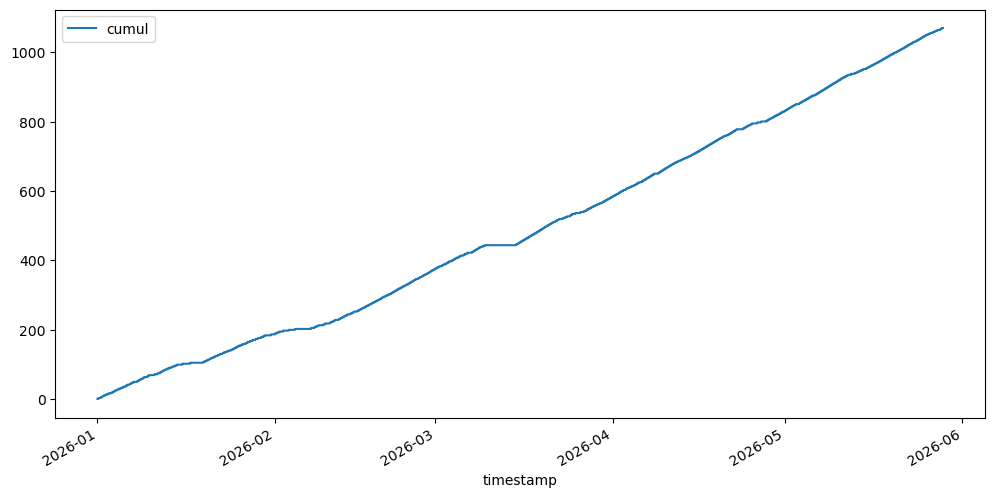

In [12]:
processor.data.plot(y=['cumul'], figsize=(12,6));

In [13]:
def l(v):
    return v*74.557 - 228.84

In [14]:
print( (l(22.22)-l(67.35))/344 * 20.9/100 )

-2.044285752005814
